# Snapget-12 — train model xác minh ảnh cho AI Daily Quest

Notebook **mỏng**: mọi logic nằm trong `ml/snapget12/` + `ml/scripts/` của repo (để review/diff được). Chạy trên **Google Colab (GPU T4)** hoặc Kaggle. Xem `Snapget/.claude/QUEST_AI_PLAN.md` mục 3–5 và `ml/README.md`.

**Trình tự:** 0 cài đặt → 1 tải COCO subset → 2 cache embedding → 3 train head v0 → 4 chọn ngưỡng + đánh giá → 5 export ONNX int8 → **upload lên Space** → (M6) 6 fine-tune v1 → 8 đánh giá v1 + Snapget-12 → 7 ablation OWL-ViT.

> ⚠️ Runtime → Change runtime type → **T4 GPU** trước khi chạy. Bước 1 tải ~7–9GB về disk Colab (không về máy). Mount Drive để giữ `data/embeddings.npz` + `artifacts/` qua các phiên.

In [1]:
# 0a. Mount Drive (giữ cache embedding + artifact qua các phiên Colab)
from google.colab import drive
drive.mount('/content/drive')
WORK = '/content/drive/MyDrive/snapget-ml'   # đổi nếu muốn
import os; os.makedirs(WORK, exist_ok=True)

Mounted at /content/drive


In [2]:
# 0b. Lấy code từ repo (đổi URL/branch cho đúng) + cài thư viện
%cd /content
!rm -rf datn && git clone --depth 1 https://github.com/HuyenVt001/datn.git datn
%cd /content/datn/ml
!pip install -q -r requirements.txt
!python -c "import torch, torchvision, fiftyone; print(torch.__version__, torch.cuda.is_available())"

/content
Cloning into 'datn'...
remote: Enumerating objects: 755, done.
remote: Counting objects: 100% (755/755), done.
remote: Compressing objects: 100% (679/679), done.
remote: Total 755 (delta 53), reused 454 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (755/755), 49.85 MiB | 2.42 MiB/s, done.
Resolving deltas: 100% (53/53), done.
/content/datn/ml
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# 0c. Trỏ data/artifacts vào Drive (symlink) để không mất khi Colab reset
!mkdir -p {WORK}/data {WORK}/artifacts
!ln -sfn {WORK}/data data && ln -sfn {WORK}/artifacts artifacts
!ls -la

total 40
drwxr-xr-x  6 root root 4096 Aug 19 04:17 .
drwxr-xr-x 10 root root 4096 Aug 19 04:16 ..
drwxr-xr-x  3 root root 4096 Aug 19 04:15 ai-service
lrwxrwxrwx  1 root root   43 Aug 19 04:17 artifacts -> /content/drive/MyDrive/snapget-ml/artifacts
lrwxrwxrwx  1 root root   38 Aug 19 04:17 data -> /content/drive/MyDrive/snapget-ml/data
-rw-r--r--  1 root root  163 Aug 19 04:15 .gitignore
drwxr-xr-x  2 root root 4096 Aug 19 04:15 notebooks
-rw-r--r--  1 root root 6115 Aug 19 04:15 README.md
-rw-r--r--  1 root root  470 Aug 19 04:15 requirements.txt
drwxr-xr-x  2 root root 4096 Aug 19 04:15 scripts
drwxr-xr-x  2 root root 4096 Aug 19 04:15 snapget12


## 1. Tải COCO 2017 subset (12 lớp + negative) → `data/manifest.csv`
Chỉ chạy lần đầu (~20–40 phút tuỳ mạng). Giảm `--max-per-class`/`--negatives` nếu hết disk.

In [7]:
!python scripts/01_prepare_coco.py --out data/manifest.csv --max-per-class 4000 --negatives 12000 --test-max 5000
!head -3 data/manifest.csv && wc -l data/manifest.csv


Extracting annotations to '/root/fiftyone/coco-2017/raw/instances_train2017.json'

Writing annotations for 4000 downloaded samples to '/root/fiftyone/coco-2017/train/labels.json'
Dataset info written to '/root/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'train'

Dataset 'coco-train-cup-42' created
[train] cup: +4000 anh (4000 co 'cup') -> tong 4000 anh
Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'
1303 images found; downloading the remaining 2697

Writing annotations for 6697 downloaded samples to '/root/fiftyone/coco-2017/train/labels.json'
Dataset info written to '/root/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'train'

Dataset 'coco-train-bottle-42' created
[train] bottle: +4000 anh (4000 co 'bottle') -> tong 6697 anh
Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'
770 images found; downloading the remaining 3230

Writing annotations for 9927 downloaded samples to '/root/fiftyone/coco-2017/train/l

## 2. Cache embedding backbone

In [8]:
!python scripts/02_cache_embeddings.py --manifest data/manifest.csv --out data/embeddings.npz --batch 128

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100% 9.83M/9.83M [00:00<00:00, 132MB/s]
embed[cpu]:   0% 0/256 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that 

## 3. Train head **v0** từ cache (~1–2 phút)

In [9]:
!python scripts/03_train_head.py --emb data/embeddings.npz --out artifacts/v0/head.pt --epochs 30

train 27693 / val 3077 embedding
pos_weight: {'cup': 4.14, 'bottle': 4.78, 'book': 5.65, 'chair': 3.35, 'potted plant': 6.44, 'laptop': 7.72, 'keyboard': 13.56, 'backpack': 5.92, 'clock': 6.62, 'umbrella': 6.73, 'bicycle': 8.45, 'motorcycle': 7.82}
epoch  1 loss 0.8177  val mAP 0.5871
epoch  2 loss 0.7232  val mAP 0.6094
epoch  3 loss 0.7020  val mAP 0.6205
epoch  4 loss 0.6886  val mAP 0.6277
epoch  5 loss 0.6749  val mAP 0.6331
epoch  6 loss 0.6657  val mAP 0.6366
epoch  7 loss 0.6578  val mAP 0.6404
epoch  8 loss 0.6498  val mAP 0.6428
epoch  9 loss 0.6417  val mAP 0.6445
epoch 10 loss 0.6349  val mAP 0.6455
epoch 11 loss 0.6276  val mAP 0.6462
epoch 12 loss 0.6221  val mAP 0.6477
epoch 13 loss 0.6163  val mAP 0.6478
epoch 14 loss 0.6095  val mAP 0.6474
epoch 15 loss 0.6046  val mAP 0.6492
epoch 16 loss 0.5994  val mAP 0.6505
epoch 17 loss 0.5939  val mAP 0.6497
epoch 18 loss 0.5887  val mAP 0.6511
epoch 19 loss 0.5857  val mAP 0.6507
epoch 20 loss 0.5818  val mAP 0.6504
epoch 21 lo

## 4. Chọn ngưỡng per-class (precision ≥ 0.8, max recall) + đánh giá COCO val/test + PR curve

thresholds: {'cup': 0.8487, 'bottle': 0.8232, 'book': 0.9091, 'chair': 0.8078, 'potted plant': 0.8291, 'laptop': 0.8796, 'keyboard': 0.9208, 'backpack': 0.8779, 'clock': 0.7067, 'umbrella': 0.7802, 'bicycle': 0.8893, 'motorcycle': 0.649}
[val] n=3077 mAP=0.652 macroF1=0.5306
   cup            thr=0.849 P=0.700 R=0.396 F1=0.506 AP=0.6542 n=613
   bottle         thr=0.823 P=0.700 R=0.366 F1=0.481 AP=0.5993 n=573
   book           thr=0.909 P=0.701 R=0.184 F1=0.292 AP=0.528 n=445
   chair          thr=0.808 P=0.700 R=0.408 F1=0.516 AP=0.646 n=698
   potted plant   thr=0.829 P=0.701 R=0.317 F1=0.436 AP=0.5179 n=385
   laptop         thr=0.880 P=0.699 R=0.542 F1=0.610 AP=0.6923 n=347
   keyboard       thr=0.921 P=0.704 R=0.535 F1=0.608 AP=0.6848 n=213
   backpack       thr=0.878 P=0.698 R=0.229 F1=0.345 AP=0.5227 n=424
   clock          thr=0.707 P=0.700 R=0.616 F1=0.655 AP=0.7336 n=398
   umbrella       thr=0.780 P=0.700 R=0.649 F1=0.674 AP=0.7679 n=385
   bicycle        thr=0.889 P=0.701 

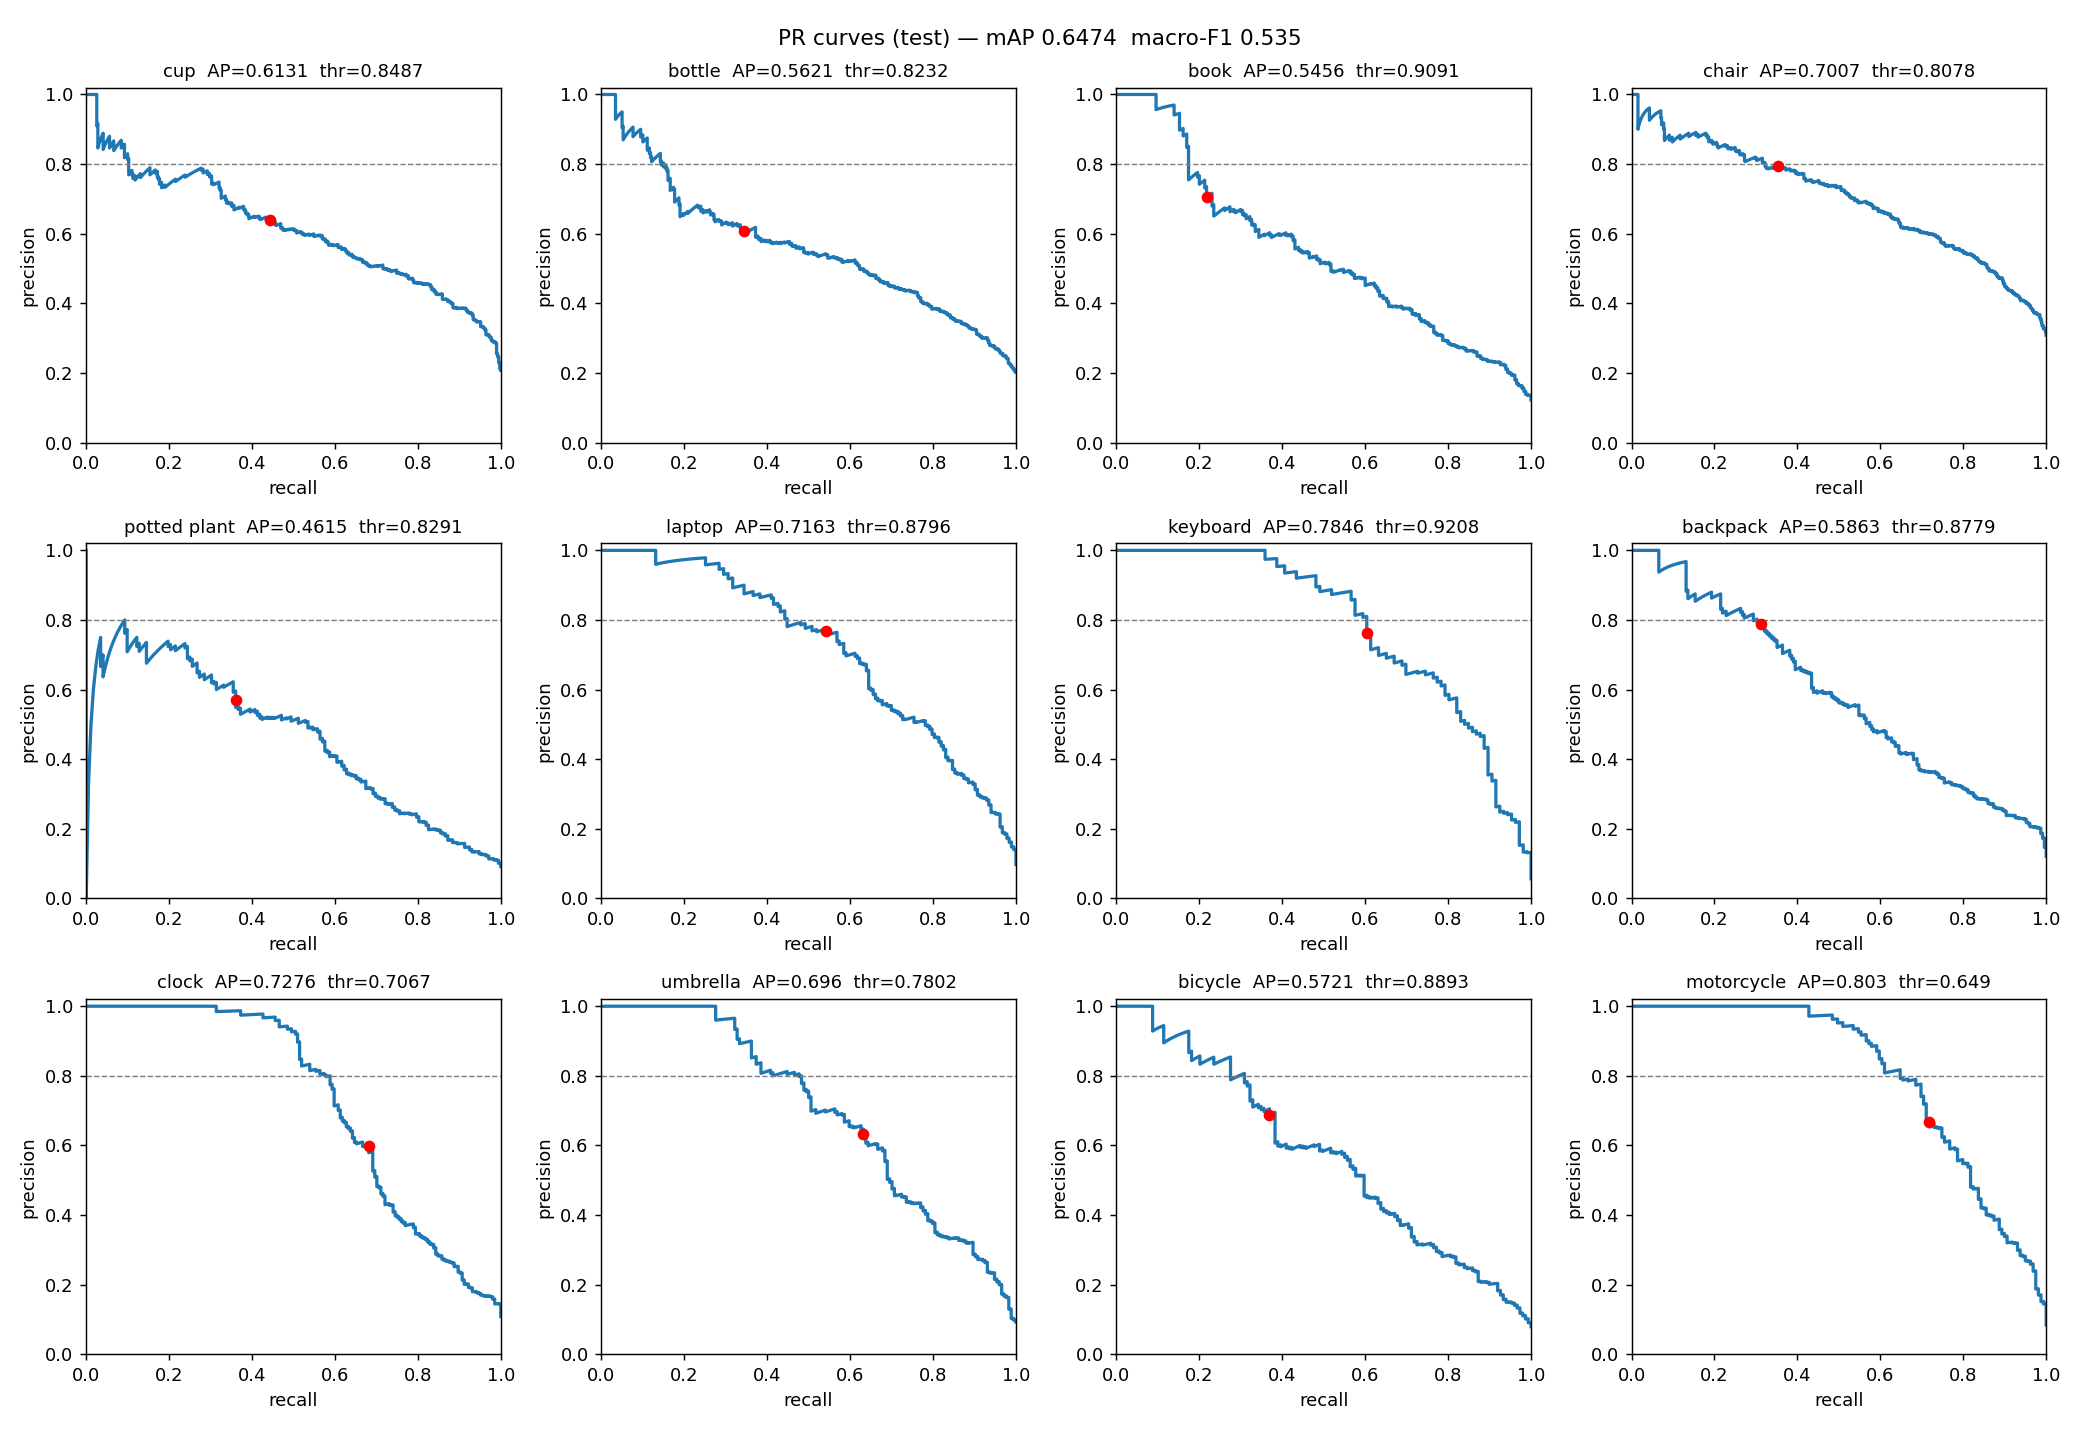

In [14]:
!python scripts/04_eval_thresholds.py --emb data/embeddings.npz --head artifacts/v0/head.pt --out artifacts/v0 --min-precision 0.7

from IPython.display import Image, display
display(Image('artifacts/v0/pr_curves_test.png'))

## 5. Export ONNX int8 + `model_meta.json` → **upload lên HF Model repo** (miễn phí)
Cần token HF quyền **write**. Điền `MODEL_REPO` = `<user>/snapget-ai-model`. Sau đó AI service trên **Cloud Run** tự tải model qua env `MODEL_REPO` (QUEST_AI_PLAN mục 17.C5b).

In [15]:
!pip install -q onnxscript

In [13]:
%cd /content/datn
!git pull
%cd /content/datn/ml
!grep -n '"--quant"' scripts/05_export_onnx.py
!rm -f artifacts/v0/model.onnx artifacts/v0/model_fp32.onnx




/content/datn
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.20 KiB | 175.00 KiB/s, done.
From https://github.com/HuyenVt001/datn
   59fd401..df7d603  main       -> origin/main
Updating 59fd401..df7d603
Fast-forward
 Snapget/.claude/QUEST_AI_PLAN.md | 2 ++
 1 file changed, 2 insertions(+)
/content/datn/ml
46:    ap.add_argument("--quant", choices=["head", "none", "full"], default="head",


In [17]:
from huggingface_hub import login
login()   # dán token write
MODEL_REPO = 'Flowerng/snapget-ai-model'   # HF MODEL repo (mien phi) — Cloud Run tai tu day
!python scripts/05_export_onnx.py --head artifacts/v0/head.pt --version v0 --out artifacts/v0 --upload {MODEL_REPO}

/content/datn/ml/scripts/05_export_onnx.py:76: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy, str(fp32_path), dynamo=False, **export_kwargs)
max |pytorch_fp32 - onnx_serve| = 0.0365   (quant=dynamic int8 head-only (MatMul))
latency onnx CPU: p50 7.2ms  p95 8.9ms
-> artifacts/v0/model.onnx (3.89 MB), model_meta.json
Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  0.00B            

  ...l/artifacts/v0/model.onnx: 100% 3.89M/3.89M [00:00<?, ?B/s]

Processing Files (1 / 1)      : 100% 3.89M/3.89M [00:00<00:00, 7.21MB/s,   ???B/s  ]

  ...l/artifacts/

✅ **Tới đây là xong M1+M2 phần model**: deploy/restart Cloud Run với `MODEL_REPO` (plan 17.C5b) rồi `GET <Service URL>/health` phải trả `modelVersion: "v0"`, `verifierReady: true`.

---
## M6 — Snapget-12, fine-tune v1, ablation

### 6a. Upload tập **Snapget-12** tự chụp
Cấu trúc thư mục (zip rồi kéo lên Drive `{WORK}/data/snapget12/`): `snapget12/cup/*.jpg`, `snapget12/bottle/*.jpg`, …, `snapget12/negative/*.jpg`. Ảnh có 2 vật thể → đặt tên `cup+book_01.jpg`. Mỗi lớp ~10 ảnh/thành viên, chụp **bằng chính app/điện thoại** (dọc, trong nhà, đèn vàng…).

In [ ]:
# 6b. Đánh giá model v0 ĐANG CHẠY (ONNX int8) trên Snapget-12 -> domain shift so với COCO test
#     (báo cáo: 3 lớp book/backpack/keyboard dự kiến thấp nhất -> lý do app chỉ ra đề 9 lớp, plan 2.3)
!python scripts/08_eval_images.py --onnx artifacts/v0/model.onnx --thresholds artifacts/v0/thresholds.json \
    --manifest data/manifest.csv --snapget12 data/snapget12 --out artifacts/v0

### 6c. Fine-tune **v1** (mở block conv cuối, augmentation crop dọc 3:4) — ~30–60 phút T4

In [ ]:
!python scripts/06_finetune_v1.py --manifest data/manifest.csv --init-head artifacts/v0/head.pt --out artifacts/v1/model.pt --epochs 8
# chọn ngưỡng trên val + đánh giá test + Snapget-12 (cùng tập với v0 để so sánh delta)
!python scripts/08_eval_images.py --full artifacts/v1/model.pt --manifest data/manifest.csv \
    --choose-thresholds-on val --snapget12 data/snapget12 --out artifacts/v1

### 6d. Export v1 → upload Model repo (thay v0) — chỉ khi v1 tốt hơn trên **Snapget-12** (rồi restart Cloud Run)

In [ ]:
!python scripts/05_export_onnx.py --full artifacts/v1/model.pt --version v1 --out artifacts/v1 --upload {MODEL_REPO}

### 7. Ablation: OWL-ViT zero-shot trên cùng 2 tập test (~150M params, vài giây/ảnh CPU)

In [ ]:
!python scripts/07_ablation_owlvit.py --manifest data/manifest.csv --snapget12 data/snapget12 --out artifacts/owlvit --max-test 1500

### 8. Bảng tổng hợp cho báo cáo

In [ ]:
import json, glob
rows = []
for name in ['v0', 'v1', 'owlvit']:
    for split in ['test', 'snapget12']:
        p = f'artifacts/{name}/metrics_{split}.json'
        try:
            m = json.load(open(p))
            rows.append((name, split, m['n'], m['mAP'], m['macroF1'], m.get('latencyMs')))
        except FileNotFoundError:
            pass
print(f"{'model':8s} {'split':10s} {'n':>6s} {'mAP':>7s} {'macroF1':>8s}  latency")
for r in rows:
    print(f"{r[0]:8s} {r[1]:10s} {r[2]:6d} {r[3]:7.4f} {r[4]:8.4f}  {r[5]}")